# HW 2
### Due Monday, Oct 13 at 11:59 PM

## Concept Covered in the Exmaple Notebook
- birtsh by year
- births by date month
- births by day of the month
- births by day of the month sans holidays
- births on the 13 relative to births not on the 13th
- births on friday vs any day

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load birth data
df = pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/data/master/births/US_births_2000-2014_SSA.csv')

# group data by year
# month_grp = df.groupby('month')
# monthly = month_grp.sum()
# monthly.index

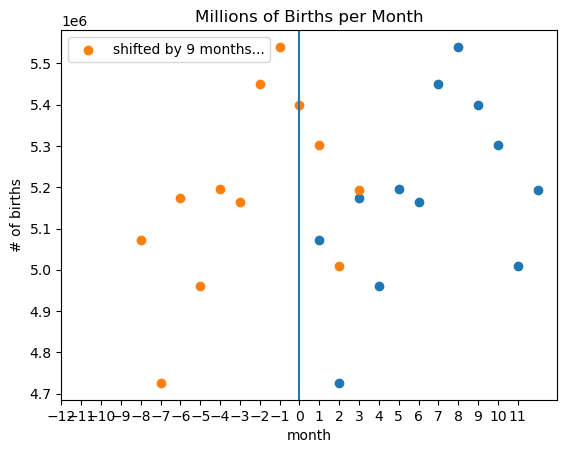

In [30]:
month_grp = df.groupby('month')
births_by_month = month_grp.sum()

plt.scatter(births_by_month.index, births_by_month.births)
plt.scatter(births_by_month.index - 9, births_by_month.births, label='shifted by 9 months...')
plt.title('Millions of Births per Month')
plt.ylabel('# of births')
plt.xlabel('month')
plt.xticks(np.arange(-12, 12, step=1))
plt.axvline(0)
plt.legend()

In [ ]:
# manually define the x-axis


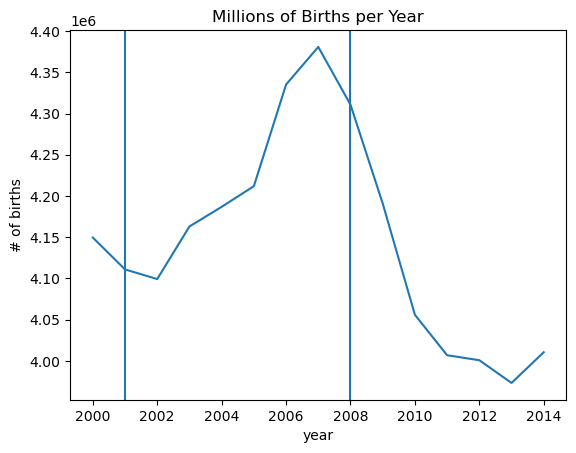

In [2]:

plt.plot(births_by_year.index, births_by_year.births)
plt.title('Millions of Births per Year')
plt.ylabel('# of births')
plt.xlabel('year')
plt.axvline(2008)
plt.axvline(2001)

In [16]:
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1,6,9083,2000-01-01
1,2000,1,2,7,8006,2000-01-01
2,2000,1,3,1,11363,2000-01-01
3,2000,1,4,2,13032,2000-01-01
4,2000,1,5,3,12558,2000-01-01
...,...,...,...,...,...,...
5474,2014,12,27,6,8656,2014-12-01
5475,2014,12,28,7,7724,2014-12-01
5476,2014,12,29,1,12811,2014-12-01
5477,2014,12,30,2,13634,2014-12-01


In [18]:
df['month'] = df['date'].dt.month
#df['year'] = df['year'].dt.year
df

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1,6,9083,2000-01-01
1,2000,1,2,7,8006,2000-01-01
2,2000,1,3,1,11363,2000-01-01
3,2000,1,4,2,13032,2000-01-01
4,2000,1,5,3,12558,2000-01-01
...,...,...,...,...,...,...
5474,2014,12,27,6,8656,2014-12-01
5475,2014,12,28,7,7724,2014-12-01
5476,2014,12,29,1,12811,2014-12-01
5477,2014,12,30,2,13634,2014-12-01


In [20]:
monthly = df.groupby('date')['births'].sum().sort_index()
monthly['date'].dt.month

KeyError: 'date'

In [6]:
shifted = monthly.shift(-9, freq='ME')
shifted

date
1999-04-30    337739
1999-05-31    324046
1999-06-30    347824
1999-07-31    323357
1999-08-31    347950
               ...  
2013-11-30    356066
2013-12-31    350497
2014-01-31    344471
2014-02-28    318655
2014-03-31    339726
Name: births, Length: 180, dtype: int64

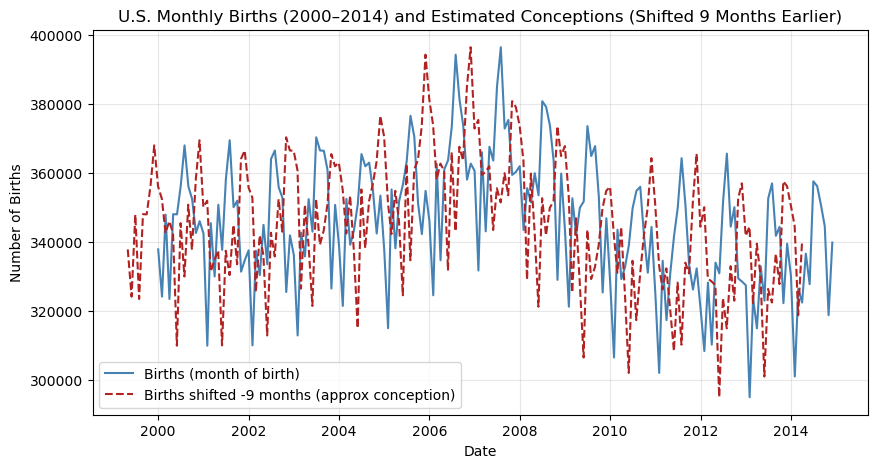

In [7]:
plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, label='Births (month of birth)', color='steelblue')
plt.plot(shifted.index, shifted.values, label='Births shifted -9 months (approx conception)', color='firebrick', linestyle='--')

plt.title('U.S. Monthly Births (2000–2014) and Estimated Conceptions (Shifted 9 Months Earlier)')
plt.xlabel('Date')
plt.ylabel('Number of Births')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

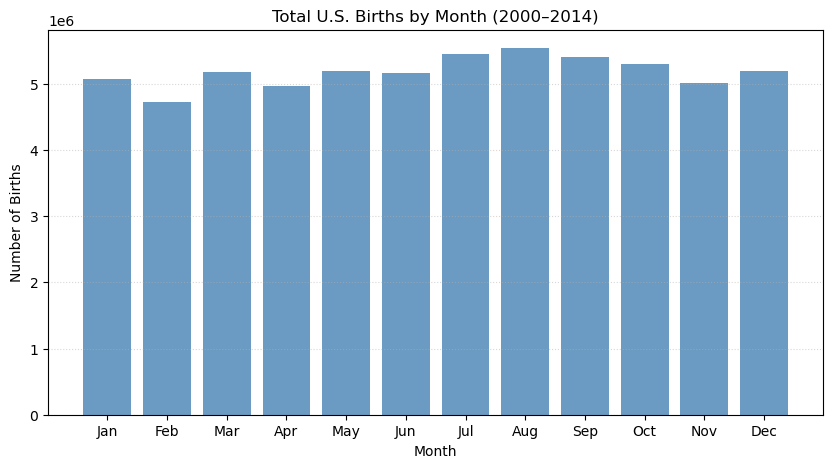

In [8]:
monthly_births = df.groupby('month')['births'].sum()

# Make the months appear in order (1–12)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10,5))
plt.bar(months, monthly_births, color='steelblue', alpha=0.8)
plt.title('Total U.S. Births by Month (2000–2014)')
plt.xlabel('Month')
plt.ylabel('Number of Births')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.show()